#### Importing Required Libararies:

In [126]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay
)

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate
import time
from sklearn.model_selection import GridSearchCV

#### Loading data and preprocessor:

In [127]:
X_train = joblib.load("../data/X_train.pkl")
X_test = joblib.load("../data/X_test.pkl")
y_train = joblib.load("../data/y_train.pkl")
y_test = joblib.load("../data/y_test.pkl")

preprocessor = joblib.load("../outputs/models/preprocessor.pkl")

# Application and Evaluation of different ML models:

I did that because it will prevent the repition of code.

#### Perform Cross Validation:

This function perform cross-validation on the training data.

In [128]:
def perform_cross_validation(pipeline, X_train, y_train):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1,
        return_train_score=False
    )

    cv_results_df = pd.DataFrame(cv_results)

    cv_results_df = cv_results_df.drop(
        columns=["fit_time", "score_time"]
    )

    return cv_results_df

#### Print Fold-wise Results:

This fuction print fold-wise cross-validation results.

In [129]:
def print_cv_fold_results(cv_results):
    df = pd.DataFrame({
        "Fold": range(1, len(cv_results["test_accuracy"]) + 1),
        "Accuracy": cv_results["test_accuracy"],
        "Precision": cv_results["test_precision"],
        "Recall": cv_results["test_recall"],
        "F1 Score": cv_results["test_f1"],
        "ROC AUC": cv_results["test_roc_auc"]
    })

    return df

#### Print Average Cross Validation Results:

Print average cross-validation metrics.

In [130]:
def print_cv_average_results(cv_results):
    cv_df = pd.DataFrame(cv_results)

    print(f"Accuracy  : {cv_df['test_accuracy'].mean():.4f}")
    print(f"Precision : {cv_df['test_precision'].mean():.4f}")
    print(f"Recall    : {cv_df['test_recall'].mean():.4f}")
    print(f"F1 Score  : {cv_df['test_f1'].mean():.4f}")
    print(f"ROC AUC   : {cv_df['test_roc_auc'].mean():.4f}")

#### Print Standard Deviation:

Print the standard deviation of cross-validation metrics.

In [131]:
def print_cv_standard_deviation(cv_results):

    cv_df = pd.DataFrame(cv_results)


    print(f"Accuracy  : {cv_df['test_accuracy'].std():.4f}")
    print(f"Precision : {cv_df['test_precision'].std():.4f}")
    print(f"Recall    : {cv_df['test_recall'].std():.4f}")
    print(f"F1 Score  : {cv_df['test_f1'].std():.4f}")
    print(f"ROC AUC   : {cv_df['test_roc_auc'].std():.4f}")

#### Fit Pipeline:

This function train the pipeline and record training time.

In [132]:
def fit_pipeline(pipeline, X_train, y_train):
    start_time = time.perf_counter()
    pipeline.fit(X_train, y_train)
    training_time = time.perf_counter() - start_time
    
    return pipeline, training_time

#### Predict:

This function generate predictions on both training and test sets.

In [133]:
def predict_pipeline(pipeline, X_train, X_test):

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):

        train_probabilities = pipeline.predict_proba(X_train)[:, 1]
        test_probabilities = pipeline.predict_proba(X_test)[:, 1]

    else:

        train_probabilities = None
        test_probabilities = None

    return (
        train_predictions,
        test_predictions,
        train_probabilities,
        test_probabilities
    )

#### Print Test Metrics:

In [135]:
def print_test_metrics(y_test, test_predictions, test_probabilities):

    accuracy = accuracy_score(y_test, test_predictions)
    precision = precision_score(y_test, test_predictions)
    recall = recall_score(y_test, test_predictions)
    f1 = f1_score(y_test, test_predictions)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    if test_probabilities is not None:
        roc_auc = roc_auc_score(y_test, test_probabilities)

        print(f"ROC AUC   : {roc_auc:.4f}")

        metrics["ROC AUC"] = roc_auc

    return metrics

#### Print Confusion Matrix:

This fuction plots confusion matrix.

In [136]:
def print_confusion_matrix(y_test, test_predictions, model_name):

    fig, ax = plt.subplots(figsize=(2, 2))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        test_predictions,
        ax=ax,
        colorbar=False
    )

    ax.set_title(f"{model_name} - Confusion Matrix")

    plt.tight_layout()
    plt.show()

#### Plot Feature importance:

This function only works for tree based models.

In [243]:
def plot_feature_importance(pipeline, feature_names, model_name, top_n=None):
    
    # Extract the trained classifier
    model = pipeline.named_steps["classifier"]

    # Ensure the model supports feature importance
    if not hasattr(model, "feature_importances_"):
        raise ValueError(f"{model_name} does not support feature_importances_.")

    # Create dataframe
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    # Sort by importance
    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    # Keep only top N features if requested
    if top_n is not None:
        importance_df = importance_df.head(top_n)

    # Plot
    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(f"{model_name} Feature Importance")

    plt.tight_layout()
    plt.show()

    return importance_df

#### Plot ROC Curve:

This function plot ROC curve if probabilities are available.

In [137]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

def plot_roc_curve(y_test, test_probabilities, model_name):

    fig, ax = plt.subplots(figsize=(3, 3))

    RocCurveDisplay.from_predictions(
        y_test,
        test_probabilities,
        ax=ax
    )

    ax.set_title(f"{model_name} - ROC Curve")

    plt.tight_layout()
    plt.show()

#### Compare Train vs Test Performance:

Compare training and test performance to check for overfitting.

In [138]:
def compare_train_vs_test(y_train, train_predictions, y_test, test_predictions):

    # Training metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    train_precision = precision_score(y_train, train_predictions)
    train_recall = recall_score(y_train, train_predictions)
    train_f1 = f1_score(y_train, train_predictions)

    # Test metrics
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_precision = precision_score(y_test, test_predictions)
    test_recall = recall_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions)

    comparison_df = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Training": [
            train_accuracy,
            train_precision,
            train_recall,
            train_f1
        ],
        "Test": [
            test_accuracy,
            test_precision,
            test_recall,
            test_f1
        ]
    })

    comparison_df["Difference"] = abs(
        comparison_df["Training"] - comparison_df["Test"]
    )

    comparison_df[["Training", "Test", "Difference"]] = comparison_df[
        ["Training", "Test", "Difference"]
    ].round(4)

    return comparison_df

### 1. Random Forest:

In [139]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

##### Perform Cross Validation:

In [140]:
cv_results = perform_cross_validation(
    pipeline=random_forest_pipeline,
    X_train=X_train,
    y_train=y_train
)

##### Print Fold-wise CV Results:

In [141]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,1.000000,0.982759,0.991304,0.999739
1,2,0.945055,0.948276,0.964912,0.956522,0.983488
2,3,0.934066,1.000000,0.894737,0.944444,0.985294
3,4,0.923077,0.962963,0.912281,0.936937,0.979876
4,5,0.989011,1.000000,0.982456,0.991150,0.999484


#####  Print Average CV Results:

In [142]:
print_cv_average_results(cv_results)

Accuracy  : 0.9560
Precision : 0.9822
Recall    : 0.9474
F1 Score  : 0.9641
ROC AUC   : 0.9896


##### Print Standard Deviation:

In [143]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0311
Precision : 0.0249
Recall    : 0.0412
F1 Score  : 0.0258
ROC AUC   : 0.0094


##### Train the Pipeline:

In [144]:
random_forest_trained_pipeline, training_time = fit_pipeline(
    pipeline=random_forest_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"\nTraining Time: {training_time:.4f} seconds")


Training Time: 0.8045 seconds


In [145]:
joblib.dump(random_forest_trained_pipeline, "../outputs/models/random_forest.pkl")

['../outputs/models/random_forest.pkl']

##### Make Predictions:

In [148]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=random_forest_trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

##### Feature importance:

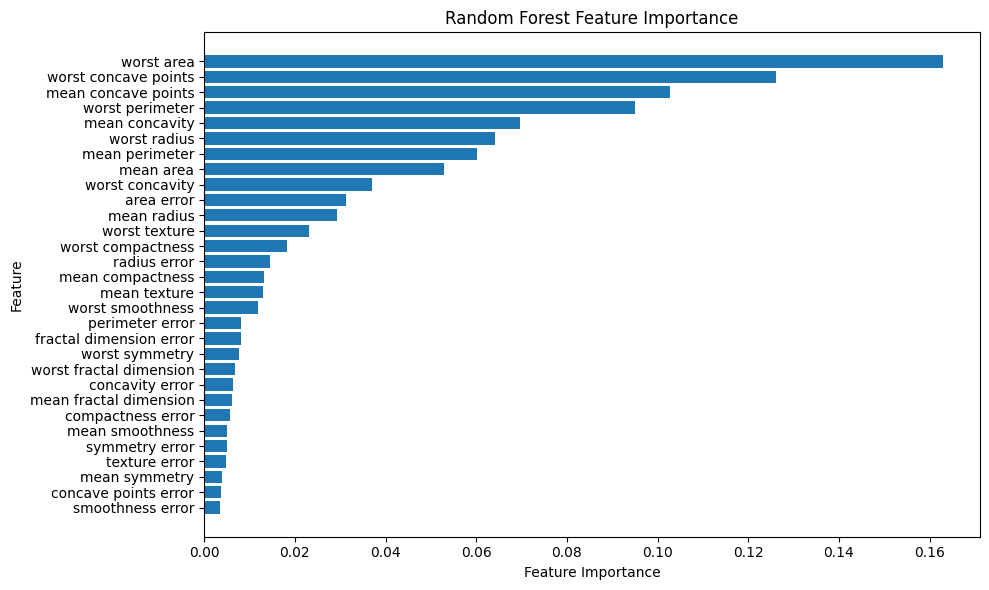

,Feature,Importance
23,worst area,0.162975
27,worst concave points,0.126056
7,mean concave points,0.102652
22,worst perimeter,0.094948
6,mean concavity,0.069710
20,worst radius,0.064148
2,mean perimeter,0.060197
3,mean area,0.052904
26,worst concavity,0.037086
13,area error,0.031231


In [244]:
plot_feature_importance(
    pipeline=random_forest_trained_pipeline,
    feature_names=X_train.columns,
    model_name="Random Forest"
)

##### Print Test Metrics:

In [149]:
metrics = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9737
Precision : 0.9857
Recall    : 0.9718
F1 Score  : 0.9787
ROC AUC   : 0.9980


##### Print Confusion Matrix:

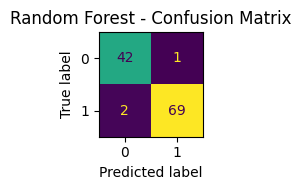

In [151]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Random Forest"
)

##### Plot ROC Curve:

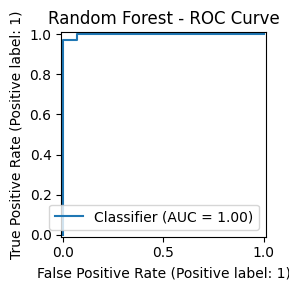

In [152]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Random Forest"
)

##### Compare Training and Test Performance:

In [153]:
compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

,Metric,Training,Test,Difference
0,Accuracy,1.0,0.9737,0.0263
1,Precision,1.0,0.9857,0.0143
2,Recall,1.0,0.9718,0.0282
3,F1 Score,1.0,0.9787,0.0213


### 2. Logistic Regression:

In [154]:
logistic_regression_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [155]:
cv_results = perform_cross_validation(
    pipeline=logistic_regression_pipeline ,
    X_train=X_train,
    y_train=y_train
)

In [156]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.956044,0.965517,0.965517,0.965517,0.995298
1,2,0.956044,0.964912,0.964912,0.964912,0.985036
2,3,0.978022,1.000000,0.964912,0.982143,0.999484
3,4,0.978022,0.982456,0.982456,0.982456,0.998452
4,5,0.978022,0.982456,0.982456,0.982456,0.997420


In [157]:
print_cv_average_results(cv_results)

Accuracy  : 0.9692
Precision : 0.9791
Recall    : 0.9721
F1 Score  : 0.9755
ROC AUC   : 0.9951


In [158]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0120
Precision : 0.0145
Recall    : 0.0095
F1 Score  : 0.0094
ROC AUC   : 0.0059


In [159]:
logistic_regression_trained_pipeline, training_time = fit_pipeline(
    pipeline=logistic_regression_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"\nTraining Time: {training_time:.4f} seconds")



Training Time: 0.0417 seconds


In [160]:
joblib.dump(logistic_regression_trained_pipeline, "../outputs/models/logistic_regression.pkl")

['../outputs/models/logistic_regression.pkl']

In [161]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=logistic_regression_trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [162]:
metrics = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)


Accuracy  : 0.9825
Precision : 0.9859
Recall    : 0.9859
F1 Score  : 0.9859
ROC AUC   : 0.9974


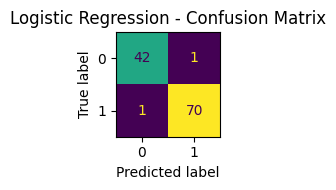

In [163]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Logistic Regression"
)

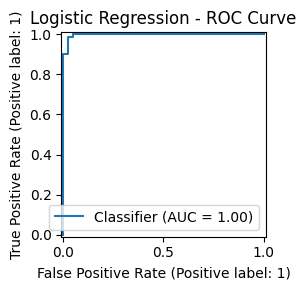

In [164]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Logistic Regression"
)

In [165]:
compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

,Metric,Training,Test,Difference
0,Accuracy,0.9890,0.9825,0.0066
1,Precision,0.9895,0.9859,0.0036
2,Recall,0.9930,0.9859,0.0071
3,F1 Score,0.9913,0.9859,0.0054


### 3. Decision Tree:

In [167]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

In [168]:
cv_results = perform_cross_validation(
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [169]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.967033,0.966102,0.982759,0.974359,0.961076
1,2,0.879121,0.883333,0.929825,0.905983,0.861971
2,3,0.890110,0.927273,0.894737,0.910714,0.888545
3,4,0.912088,0.962264,0.894737,0.927273,0.917957
4,5,0.912088,0.915254,0.947368,0.931034,0.900155


In [170]:
print_cv_average_results(cv_results)

Accuracy  : 0.9121
Precision : 0.9308
Recall    : 0.9299
F1 Score  : 0.9299
ROC AUC   : 0.9059


In [171]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0339
Precision : 0.0344
Recall    : 0.0373
F1 Score  : 0.0270
ROC AUC   : 0.0369


In [172]:
decision_tree_trained_pipeline, training_time = fit_pipeline(
    pipeline=decision_tree_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0506 seconds


In [173]:
joblib.dump(decision_tree_trained_pipeline, "../outputs/models/decision_tree.pkl")

['../outputs/models/decision_tree.pkl']

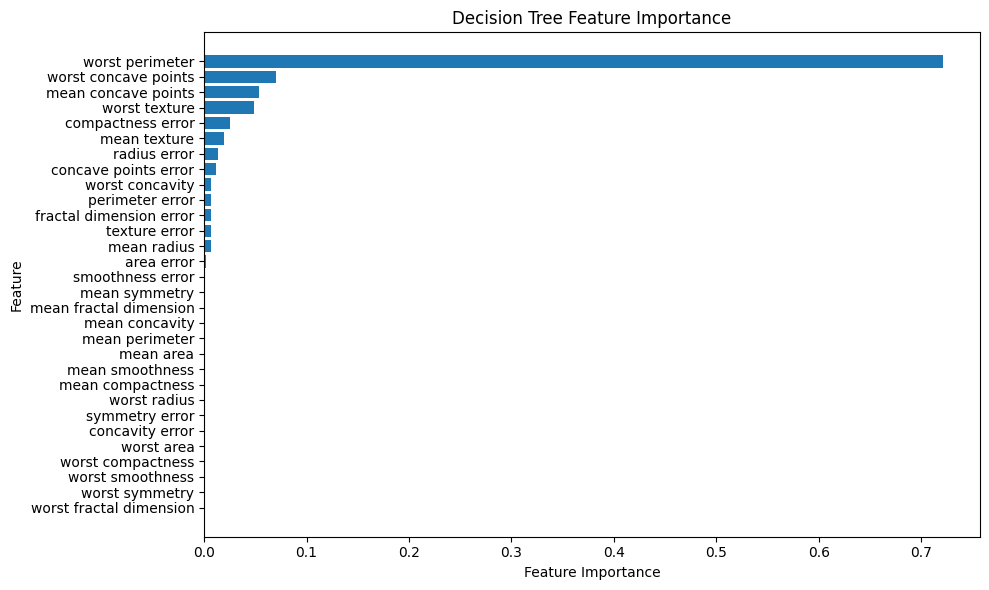

,Feature,Importance
22,worst perimeter,0.721375
27,worst concave points,0.070512
7,mean concave points,0.053089
21,worst texture,0.048787
15,compactness error,0.025615
1,mean texture,0.019365
10,radius error,0.013435
17,concave points error,0.011322
26,worst concavity,0.006853
12,perimeter error,0.006801


In [245]:
plot_feature_importance(
    pipeline=decision_tree_trained_pipeline,
    feature_names=X_train.columns,
    model_name="Decision Tree"
)

In [174]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=decision_tree_trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [175]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9577
F1 Score  : 0.9784
ROC AUC   : 0.9789


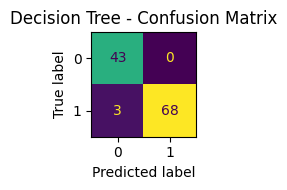

In [176]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Decision Tree"
)

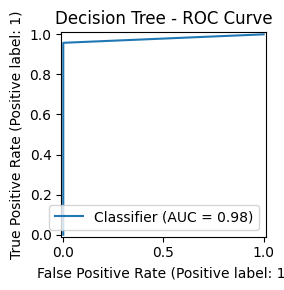

In [177]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Decision Tree"
)

In [178]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,1.0,0.9737,0.0263
1,Precision,1.0,1.0000,0.0000
2,Recall,1.0,0.9577,0.0423
3,F1 Score,1.0,0.9784,0.0216


### 4. XgBoost:

In [179]:
xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [181]:
cv_results = perform_cross_validation(
    pipeline=xgboost_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [182]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998955
1,2,0.945055,0.933333,0.982456,0.957265,0.977296
2,3,0.912088,0.962264,0.894737,0.927273,0.989680
3,4,0.956044,0.981818,0.947368,0.964286,0.989680
4,5,0.978022,0.982456,0.982456,0.982456,0.998968


In [183]:
print_cv_average_results(cv_results)

Accuracy  : 0.9560
Precision : 0.9686
Recall    : 0.9614
F1 Score  : 0.9645
ROC AUC   : 0.9909


In [184]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0301
Precision : 0.0216
Recall    : 0.0419
F1 Score  : 0.0249
ROC AUC   : 0.0089


In [185]:
xgboost_trained_pipeline, training_time = fit_pipeline(
    pipeline=xgboost_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.3629 seconds


In [186]:
joblib.dump(xgboost_trained_pipeline, "../outputs/models/xgboost.pkl")

['../outputs/models/xgboost.pkl']

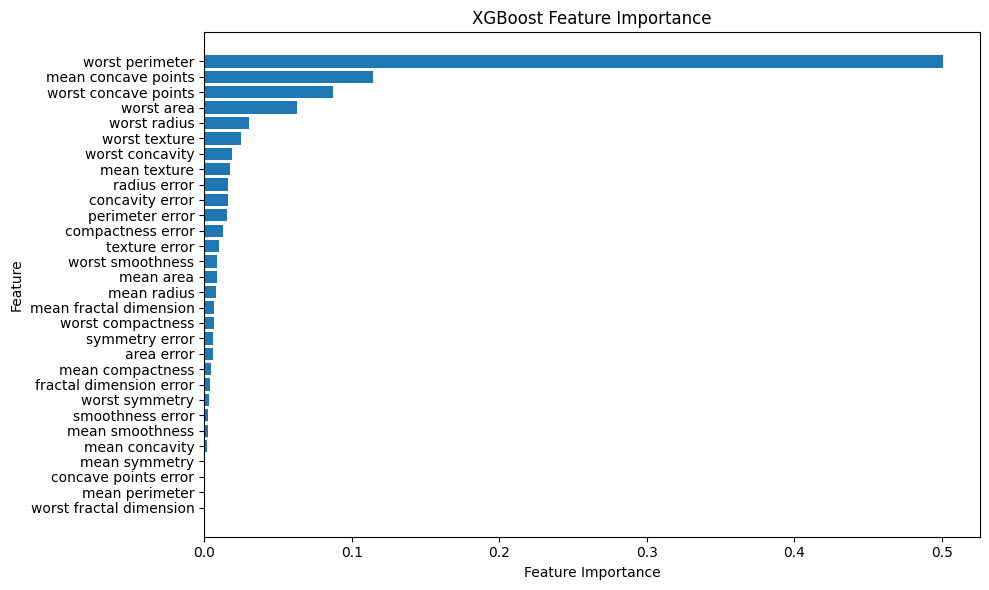

,Feature,Importance
22,worst perimeter,0.500681
7,mean concave points,0.114285
27,worst concave points,0.087493
23,worst area,0.063093
20,worst radius,0.030496
21,worst texture,0.025063
26,worst concavity,0.018800
1,mean texture,0.017770
10,radius error,0.016476
16,concavity error,0.016449


In [246]:
plot_feature_importance(
    pipeline=xgboost_trained_pipeline,
    feature_names=X_train.columns,
    model_name="XGBoost"
)

In [187]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=xgboost_trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [188]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9649
Precision : 0.9718
Recall    : 0.9718
F1 Score  : 0.9718
ROC AUC   : 0.9957


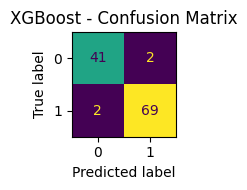

In [189]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="XGBoost"
)

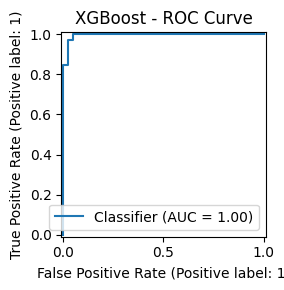

In [190]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="XGBoost"
)

In [191]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,1.0,0.9649,0.0351
1,Precision,1.0,0.9718,0.0282
2,Recall,1.0,0.9718,0.0282
3,F1 Score,1.0,0.9718,0.0282


### 5. Gradient Boosting:

In [192]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

In [193]:
cv_results = perform_cross_validation(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [194]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998433
1,2,0.956044,0.949153,0.982456,0.965517,0.980908
2,3,0.923077,0.980769,0.894737,0.935780,0.991744
3,4,0.934066,0.963636,0.929825,0.946429,0.987100
4,5,1.000000,1.000000,1.000000,1.000000,1.000000


In [195]:
print_cv_average_results(cv_results)

Accuracy  : 0.9604
Precision : 0.9753
Recall    : 0.9614
F1 Score  : 0.9678
ROC AUC   : 0.9916


In [196]:
gradient_boosting_trained_pipeline, training_time = fit_pipeline(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 2.1409 seconds


In [197]:
joblib.dump(gradient_boosting_trained_pipeline, "../outputs/models/gradient_boosting.pkl")

['../outputs/models/gradient_boosting.pkl']

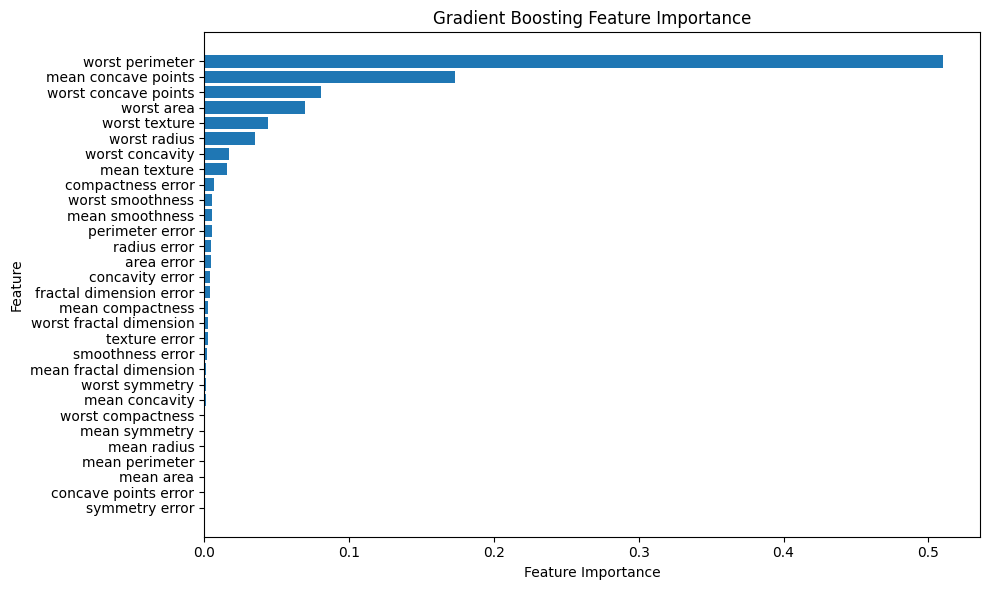

,Feature,Importance
22,worst perimeter,0.510111
7,mean concave points,0.173210
27,worst concave points,0.080325
23,worst area,0.069836
21,worst texture,0.044047
20,worst radius,0.034812
26,worst concavity,0.017377
1,mean texture,0.015668
15,compactness error,0.006507
24,worst smoothness,0.005515


In [247]:
plot_feature_importance(
    pipeline=gradient_boosting_trained_pipeline,
    feature_names=X_train.columns,
    model_name="Gradient Boosting"
)

In [198]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=gradient_boosting_trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [199]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9649
Precision : 0.9718
Recall    : 0.9718
F1 Score  : 0.9718
ROC AUC   : 0.9971


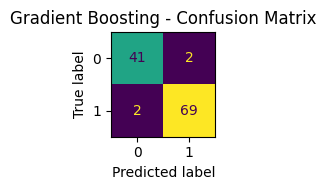

In [200]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Gradient Boosting"
)

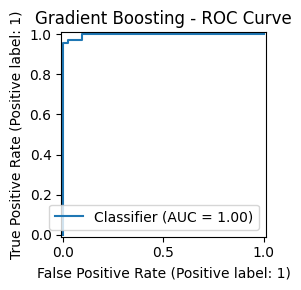

In [201]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Gradient Boosting"
)

In [202]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,1.0,0.9649,0.0351
1,Precision,1.0,0.9718,0.0282
2,Recall,1.0,0.9718,0.0282
3,F1 Score,1.0,0.9718,0.0282


### 6. Support Vector Machine(SVM):

In [203]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", SVC(
        probability=True,
        random_state=42
    ))
])

In [204]:
cv_results = perform_cross_validation(
    pipeline=gradient_boosting_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [205]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.989011,0.983051,1.000000,0.991453,0.998433
1,2,0.956044,0.949153,0.982456,0.965517,0.980908
2,3,0.923077,0.980769,0.894737,0.935780,0.991744
3,4,0.934066,0.963636,0.929825,0.946429,0.987100
4,5,1.000000,1.000000,1.000000,1.000000,1.000000


In [206]:
print_cv_average_results(cv_results)

Accuracy  : 0.9604
Precision : 0.9753
Recall    : 0.9614
F1 Score  : 0.9678
ROC AUC   : 0.9916


In [207]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0335
Precision : 0.0195
Recall    : 0.0471
F1 Score  : 0.0278
ROC AUC   : 0.0079


In [208]:
svm_trained_pipeline, training_time = fit_pipeline(
    pipeline=svm_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.1135 seconds


In [ ]:
joblib.dump(svm_trained_pipeline, "../outputs/models/svm.pkl")

In [209]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=svm_trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [210]:
_= print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9737
Precision : 0.9722
Recall    : 0.9859
F1 Score  : 0.9790
ROC AUC   : 0.9971


In [ ]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="Support Vector Machine"
)

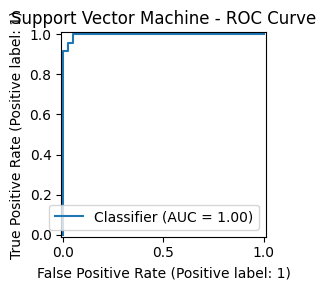

In [211]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="Support Vector Machine"
)

In [213]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9737,0.0109
1,Precision,0.9827,0.9722,0.0105
2,Recall,0.9930,0.9859,0.0071
3,F1 Score,0.9878,0.9790,0.0088


### 7. KNN 

In [214]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

In [215]:
cv_results = perform_cross_validation(
    pipeline=knn_pipeline,
    X_train=X_train,
    y_train=y_train
)

In [216]:
print_cv_fold_results(cv_results)

,Fold,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,1,0.967033,0.966102,0.982759,0.974359,0.997388
1,2,0.956044,0.949153,0.982456,0.965517,0.981682
2,3,0.967033,0.982143,0.964912,0.973451,0.993808
3,4,0.967033,0.965517,0.982456,0.973913,0.980392
4,5,0.934066,0.932203,0.964912,0.948276,0.994582


In [217]:
print_cv_average_results(cv_results)

Accuracy  : 0.9582
Precision : 0.9590
Recall    : 0.9755
F1 Score  : 0.9671
ROC AUC   : 0.9896


In [218]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0143
Precision : 0.0190
Recall    : 0.0097
F1 Score  : 0.0111
ROC AUC   : 0.0079


In [219]:
print_cv_standard_deviation(cv_results)

Accuracy  : 0.0143
Precision : 0.0190
Recall    : 0.0097
F1 Score  : 0.0111
ROC AUC   : 0.0079


In [220]:
knn_trained_pipeline, training_time = fit_pipeline(
    pipeline=knn_pipeline,
    X_train=X_train,
    y_train=y_train
)

print(f"Training Time: {training_time:.4f} seconds")

Training Time: 0.0245 seconds


In [ ]:
joblib.dump(knn_trained_pipeline, "../outputs/models/knn.pkl")

In [221]:
(
    train_predictions,
    test_predictions,
    train_probabilities,
    test_probabilities
) = predict_pipeline(
    pipeline=knn_trained_pipeline,
    X_train=X_train,
    X_test=X_test
)

In [222]:
_ = print_test_metrics(
    y_test=y_test,
    test_predictions=test_predictions,
    test_probabilities=test_probabilities
)

Accuracy  : 0.9561
Precision : 0.9714
Recall    : 0.9577
F1 Score  : 0.9645
ROC AUC   : 0.9759


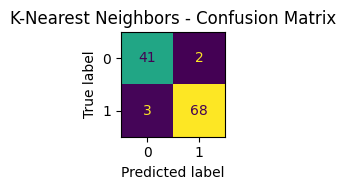

In [223]:
print_confusion_matrix(
    y_test=y_test,
    test_predictions=test_predictions,
    model_name="K-Nearest Neighbors"
)

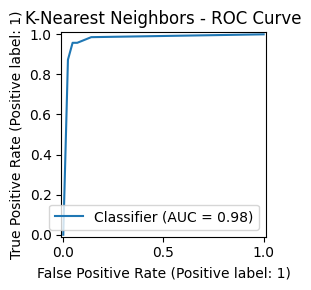

In [224]:
plot_roc_curve(
    y_test=y_test,
    test_probabilities=test_probabilities,
    model_name="K-Nearest Neighbors"
)

In [225]:
comparison_df = compare_train_vs_test(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions
)

comparison_df

,Metric,Training,Test,Difference
0,Accuracy,0.9846,0.9561,0.0285
1,Precision,0.9827,0.9714,0.0113
2,Recall,0.9930,0.9577,0.0353
3,F1 Score,0.9878,0.9645,0.0233


## Comparison of all the models:

In [226]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Dictionary containing all trained models
models = {
    "Logistic Regression": logistic_regression_trained_pipeline,
    "Decision Tree": decision_tree_trained_pipeline,
    "Random Forest": random_forest_trained_pipeline,
    "Gradient Boosting": gradient_boosting_trained_pipeline,
    "XGBoost": xgboost_trained_pipeline,
    "SVM": svm_trained_pipeline,
    "KNN": knn_trained_pipeline
}

# Store results
results = []

for model_name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(results)

# Round values to 4 decimal places
comparison_df = comparison_df.round(4)

# Display
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9825,0.9859,0.9859,0.9859,0.9974
1,Decision Tree,0.9737,1.0000,0.9577,0.9784,0.9789
2,Random Forest,0.9737,0.9857,0.9718,0.9787,0.9980
3,Gradient Boosting,0.9649,0.9718,0.9718,0.9718,0.9971
4,XGBoost,0.9649,0.9718,0.9718,0.9718,0.9957
5,SVM,0.9737,0.9722,0.9859,0.9790,0.9971
6,KNN,0.9561,0.9714,0.9577,0.9645,0.9759


## Training and Testing Results comparison:

In [227]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_regression_trained_pipeline,
    "Decision Tree": decision_tree_trained_pipeline,
    "Random Forest": random_forest_trained_pipeline,
    "Gradient Boosting": gradient_boosting_trained_pipeline,
    "XGBoost": xgboost_trained_pipeline,
    "SVM": svm_trained_pipeline,
    "KNN": knn_trained_pipeline
}

results = []

for model_name, model in models.items():

    # =========================
    # Training Predictions
    # =========================
    train_pred = model.predict(X_train)
    train_prob = model.predict_proba(X_train)[:, 1]

    # =========================
    # Test Predictions
    # =========================
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]

    # =========================
    # Calculate Metrics
    # =========================
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    train_precision = precision_score(y_train, train_pred)
    test_precision = precision_score(y_test, test_pred)

    train_recall = recall_score(y_train, train_pred)
    test_recall = recall_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred)
    test_f1 = f1_score(y_test, test_pred)

    train_auc = roc_auc_score(y_train, train_prob)
    test_auc = roc_auc_score(y_test, test_prob)

    results.append({
        "Model": model_name,

        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Accuracy Gap": abs(train_accuracy - test_accuracy),

        "Train Precision": train_precision,
        "Test Precision": test_precision,
        "Precision Gap": abs(train_precision - test_precision),

        "Train Recall": train_recall,
        "Test Recall": test_recall,
        "Recall Gap": abs(train_recall - test_recall),

        "Train F1": train_f1,
        "Test F1": test_f1,
        "F1 Gap": abs(train_f1 - test_f1),

        "Train ROC-AUC": train_auc,
        "Test ROC-AUC": test_auc,
        "ROC-AUC Gap": abs(train_auc - test_auc)
    })

comparison_df = pd.DataFrame(results)

# Round all numeric columns
comparison_df = comparison_df.round(4)

comparison_df

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Train Precision,Test Precision,Precision Gap,Train Recall,Test Recall,Recall Gap,Train F1,Test F1,F1 Gap,Train ROC-AUC,Test ROC-AUC,ROC-AUC Gap
0,Logistic Regression,0.9890,0.9825,0.0066,0.9895,0.9859,0.0036,0.993,0.9859,0.0071,0.9913,0.9859,0.0054,0.9973,0.9974,0.0001
1,Decision Tree,1.0000,0.9737,0.0263,1.0000,1.0000,0.0000,1.000,0.9577,0.0423,1.0000,0.9784,0.0216,1.0000,0.9789,0.0211
2,Random Forest,1.0000,0.9737,0.0263,1.0000,0.9857,0.0143,1.000,0.9718,0.0282,1.0000,0.9787,0.0213,1.0000,0.9980,0.0020
3,Gradient Boosting,1.0000,0.9649,0.0351,1.0000,0.9718,0.0282,1.000,0.9718,0.0282,1.0000,0.9718,0.0282,1.0000,0.9971,0.0029
4,XGBoost,1.0000,0.9649,0.0351,1.0000,0.9718,0.0282,1.000,0.9718,0.0282,1.0000,0.9718,0.0282,1.0000,0.9957,0.0043
5,SVM,0.9846,0.9737,0.0109,0.9827,0.9722,0.0105,0.993,0.9859,0.0071,0.9878,0.9790,0.0088,0.9978,0.9971,0.0007
6,KNN,0.9846,0.9561,0.0285,0.9827,0.9714,0.0113,0.993,0.9577,0.0353,0.9878,0.9645,0.0233,0.9986,0.9759,0.0227


### Selection of best model:

I am considering <b>mainly</b> these metrics for the model selection:

1. <b>Recall:</b> I have learnt that in medical field, it is dangerous that if someone has a disease and model predicts that the patient has no disease. So, the rate of false negatives(recall) should be less.
2. <b>Overfitting:</b> If a model overfits, then it will perform poorly on entirely new data.
3. <b>Accuracy:</b> It shows overall how the model is performing.

Based on these matrices, I have concluded that <b>Logistic Regression</b> is the best model.

#### Reasons:

<b>Recall</b>: Logistic Regression has highest recall(98.59%).

<b>Overfitting:</b> It has the lowest train-test gap. Mainly in the case of Recall, the gap between recall during training is 0.0071 and in the case of Accuracy, its 0.0066. Same goes with precision and f1-score, the training and testing gap is lowest.

### Hyperparameter Tuning using GridSearch CV:

##### Initialization of parameter grid:

In [228]:
param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__max_iter": [100, 300, 500]
}

##### Grid Search:

In [234]:
grid_search = GridSearchCV(
    estimator=logistic_regression_trained_pipeline,          # Logistic Regression pipeline
    param_grid=param_grid,
    scoring="recall",            # Prioritize recall for breast cancer detection
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scaler',
                                                                         StandardScaler(),
                                                                         ['mean '
                                                                          'radius',
                                                                          'mean '
                                                                          'texture',
                                                                          'mean '
                                                                          'perimeter',
                                                                          'mean '
                                                                          'area',
                                                                          'mean '
                                                                          'smoothness',
                                                                          'mean '
                                                                          'compactness',
                                                                          'mean '
                                                                          'concavity',
                                                                          'mean '
                                                                          'concave '
                                                                          'points',
                                                                          'mean '
                                                                          'symmetry',
                                                                          'mean '
                                                                          'fractal '
                                                                          'dimension',
                                                                          'radius '
                                                                          'error',
                                                                          'te...
                                                                          'dimension'])])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__max_iter': [100, 300, 500],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear']},
             scoring='recall', verbose=2)

##### Best Parameters:

In [235]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__max_iter': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


##### Best pipeline:

In [236]:
best_logistic_regression_pipeline = grid_search.best_estimator_
best_logistic_regression_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['mean radius',
                                                   'mean texture',
                                                   'mean perimeter',
                                                   'mean area',
                                                   'mean smoothness',
                                                   'mean compactness',
                                                   'mean concavity',
                                                   'mean concave points',
                                                   'mean symmetry',
                                                   'mean fractal dimension',
                                                   'radius error',
                                                   'texture error',
                                                   'perimeter error',
                                                   'area error',
                                                   'smoothness er...
                                                   'concave points error',
                                                   'symmetry error',
                                                   'fractal dimension error',
                                                   'worst radius',
                                                   'worst texture',
                                                   'worst perimeter',
                                                   'worst area',
                                                   'worst smoothness',
                                                   'worst compactness',
                                                   'worst concavity',
                                                   'worst concave points',
                                                   'worst symmetry',
                                                   'worst fractal '
                                                   'dimension'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(C=10, random_state=42,
                                    solver='liblinear'))])

##### Evaluating hypermater tuned pipeline:

In [237]:
# Make predictions
y_pred = best_pipeline.predict(X_test)

# Prediction probabilities
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print metrics
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.9737
Precision: 0.9857
Recall   : 0.9718
F1 Score : 0.9787
ROC-AUC  : 0.9961


##### Classification Report:

In [238]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



##### Confusion Matrix:

In [239]:
print(confusion_matrix(y_test, y_pred))

[[42  1]
 [ 2 69]]


### Final Decision after Hyperparameter tuning:

After performing hyperparameter tuning on the best performing model, I analyzed the results, I found out that after hyperparameter tuning, the performance of the model in every metric decrased, so I am deciding to go with the default logistic regression pipeline.